# Backbone ablation

**Backbones**
- `resnet50` - ImageNet-pretrained ResNet-50.
- `resnet50-arctic` - ResNet-50 initialized from the ARCTIC checkpoint instead of ImageNet.
- `resnet101` - deeper ResNet.
- `mobilenet_v3_l` - efficient CNN (large).
- `convnext_l` - modern CNN (large).
- `mobilevit_s` - hybrid CNN/ViT (small).
- `swinv2_b` - Swin Transformer V2 (base).
- `wave_vit_s` - wavelet vision transformer.

**Evaluation Datasets**
- In-distribution (seen in the training mix): `arctic`, `assembly`.
- Zero-shot (held out): `h2o`, `epic_handkps`, `egoexo`.

**Metrics** (lower is better)
- `mpjpe` - root aligned MPJPE, mm. Primary 3D accuracy metric.
- `mrrpe` - relative root position error between the two hands, mm.
- `pix_err` - per joint 2D error in the 224px patch, px.

## Understanding the metrics

`mpjpe` and `mrrpe` are computed in `src/metrics.py` over the 21 MANO hand joints
(joint 0 = wrist/root), in millimeters, lower is better; `pix_err` is a 2D
error in pixels.

### `mpjpe` - Root Aligned Mean Per-Joint Position Error
Average Euclidean distance between predicted and ground truth 3D joints, meaned over the 21
joints, after translating both hands such that the wrist sits at the origin. This
removes the hand's absolute camera position and measures the articulated pose
plus its global orientation.

### `mrrpe` - Mean Relative-Root Position Error (Right vs Left)
Measures the two hands' placement relative to each other (the error in the
right minus left wrist displacement vector). It requires the predicted camera translation
to be roughly correct, which is why it is the most fragile zero-shot (it blows up
on unseen cameras). It is only defined when both hands are present.

### `pix_err` - 2D pixel error (224px patch)
Per-joint Euclidean distance between predicted and GT 2D keypoints in the 224×224 patch.
Like `mrrpe` it flows through the predicted camera, so it also blows up on unseen cameras.

| Metric | Removes | Measures | Most sensitive to |
|---|---|---|---|
| `mrrpe` | common global offset only | inter-hand 3D placement | camera translation |
| `mpjpe` | per-hand translation | pose + global orientation | wrist orientation + articulation |
| `pix_err` | nothing (absolute 2D) | reprojected 2D placement | camera translation |

`mpjpe` transfers across cameras and is the fair zero-shot accuracy number. The absolute
placement metrics (`mrrpe`, `pix_err`) are driven by the camera translation head, which does
not transfer to unseen cameras at this data scale and can blow up by orders of magnitude.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_theme(style="whitegrid", context="talk")

candidates = [Path.cwd() / "results" / "ablation.csv", Path.cwd().parent / "results" / "ablation.csv"]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df = pd.read_csv(csv_path)

IN_DIST = {"arctic", "assembly"}
df["regime"] = df["dataset"].map(lambda d: "in-distribution" if d in IN_DIST else "zero-shot")
df["units"] = df["metric"].map({"mpjpe": "mm", "mrrpe": "mm", "pix_err": "px"})

BACKBONE_ORDER = ["resnet50", "resnet50-arctic", "resnet101", "mobilenet_v3_l", "convnext_l", "mobilevit_s", "swinv2_b", "wave_vit_s"]
DATASET_ORDER = ["arctic", "assembly", "h2o", "epic_handkps", "egoexo"]
METRIC_ORDER = ["mpjpe", "mrrpe", "pix_err"]

def _ordered(values, order):
    present = order + sorted(set(values) - set(order))
    return pd.Categorical(values, [v for v in present if v in set(values)], ordered=True)

df["backbone"] = _ordered(df["backbone"], BACKBONE_ORDER)
df["dataset"] = _ordered(df["dataset"], DATASET_ORDER)
df["metric"] = _ordered(df["metric"], METRIC_ORDER)
df = df.sort_values(["metric", "dataset", "backbone"]).reset_index(drop=True)

print(f"loaded {len(df)} rows from {csv_path}")

loaded 96 rows from c:\Users\brett\Desktop\School\UCSD_MS\ECE_228\Final_Project\results\ablation.csv


## Summary table

Backbones (columns) by metric and dataset (rows). Lower is better. Each row is colored independently (green = best backbone for that metric/dataset, red = worst).

In [6]:
table = df.pivot_table(index=["metric", "dataset"], columns="backbone", values="value", observed=True)
table.style.format("{:.1f}", na_rep="\u2014").background_gradient(cmap="RdYlGn_r", axis=1)

## Root aligned MPJPE

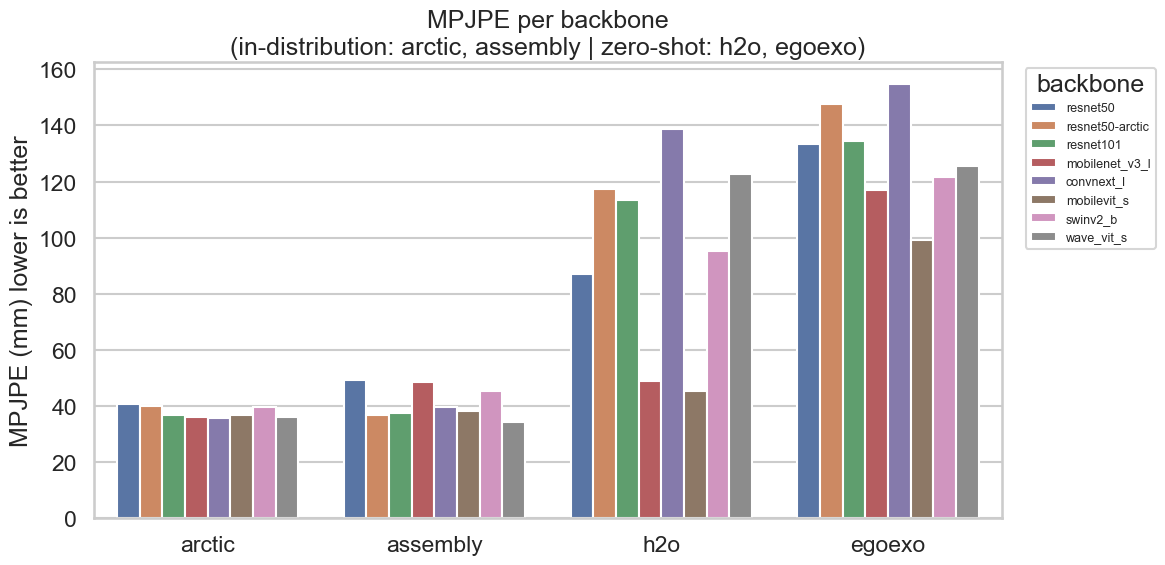

In [16]:
mpjpe = df[df["metric"] == "mpjpe"].copy()
mpjpe["dataset"] = mpjpe["dataset"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=mpjpe, x="dataset", y="value", hue="backbone", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("MPJPE (mm) lower is better")
ax.set_title("MPJPE per backbone\n(in-distribution: arctic, assembly | zero-shot: h2o, egoexo)")
ax.legend(title="backbone", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## MRRPE

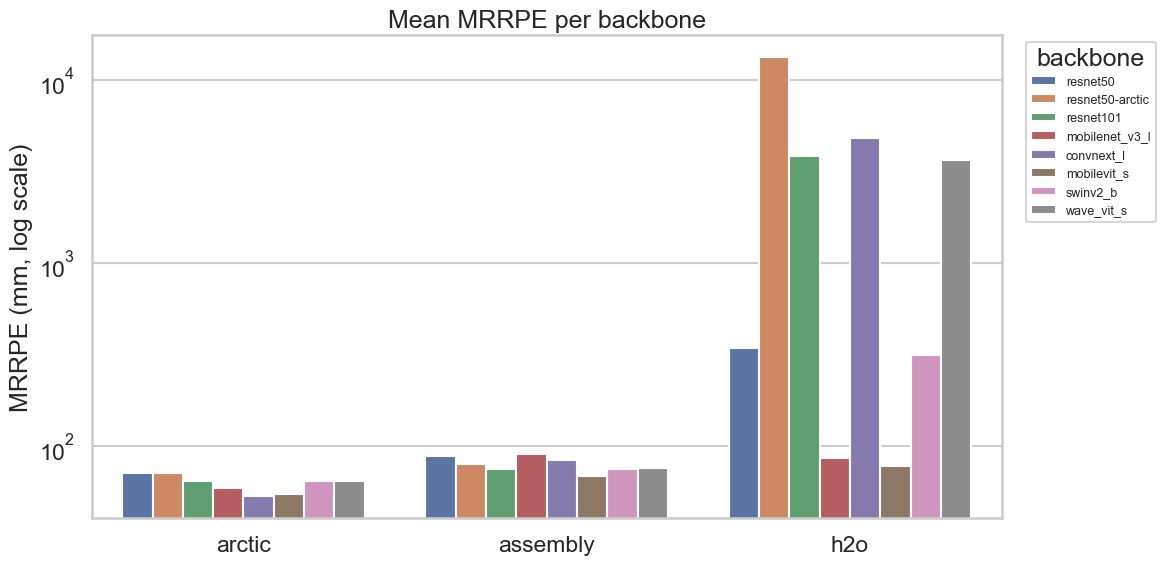

In [14]:
mrrpe = df[df["metric"] == "mrrpe"].copy()
mrrpe["dataset"] = mrrpe["dataset"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=mrrpe, x="dataset", y="value", hue="backbone", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("MRRPE (mm, log scale)")
ax.set_yscale("log")
ax.set_title("Mean MRRPE per backbone")
ax.legend(title="backbone", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Pixel error

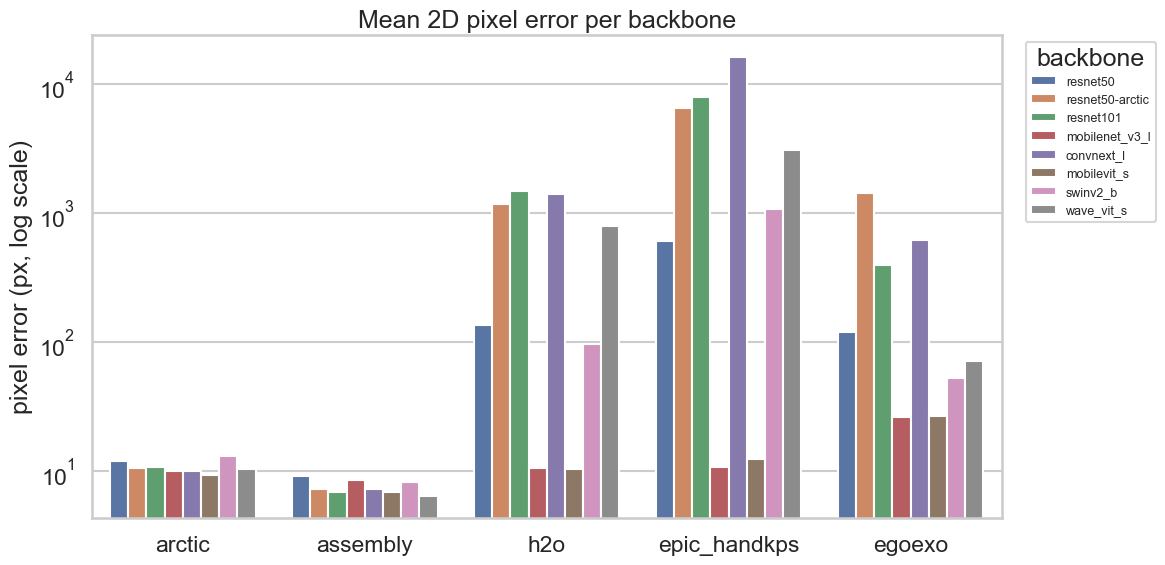

In [15]:
pix = df[df["metric"] == "pix_err"].copy()
pix["dataset"] = pix["dataset"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=pix, x="dataset", y="value", hue="backbone", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("pixel error (px, log scale)")
ax.set_yscale("log")
ax.set_title("Mean 2D pixel error per backbone")
ax.legend(title="backbone", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()